# Cell 1 – Import required libraries

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from transformers import ConvNextForImageClassification, AutoImageProcessor
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

c:\Users\PC\anaconda3\lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


# Cell 2 – Set device and dataset paths

In [2]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths (adjust if your folder structure differs)
data_root = r"C:\Users\PC\Desktop\classification tasks\NWPU-RESISC45\Dataset"
train_dir = os.path.join(data_root, "train", "train")   # nested train folder
test_dir  = os.path.join(data_root, "test", "test")     # nested test folder

print(f"Train images root: {train_dir}")
print(f"Test images root: {test_dir}")

Using device: cuda
Train images root: C:\Users\PC\Desktop\classification tasks\NWPU-RESISC45\Dataset\train\train
Test images root: C:\Users\PC\Desktop\classification tasks\NWPU-RESISC45\Dataset\test\test


# Cell 3 – Explore dataset and visualise sample images

Number of classes: 45
Class names: ['airplane', 'airport', 'baseball_diamond', 'basketball_court', 'beach'] ...
Images per class: min=600, max=600


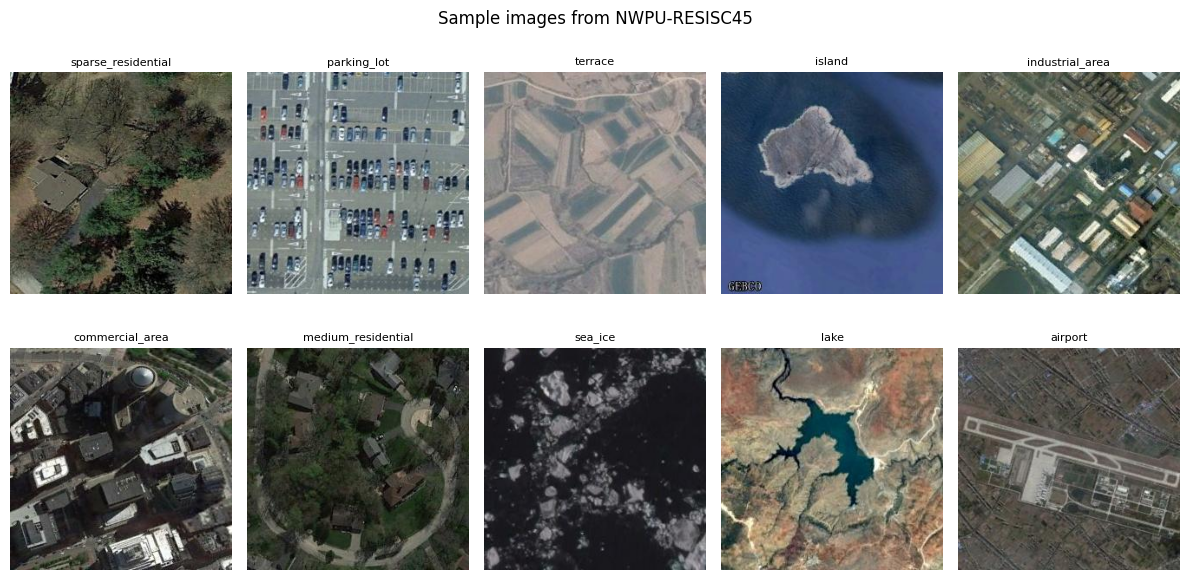

In [3]:
# Load the training dataset without transformations (just to get classes)
temp_dataset = datasets.ImageFolder(train_dir)
classes = temp_dataset.classes
num_classes = len(classes)
print(f"Number of classes: {num_classes}")
print("Class names:", classes[:5], "...")  # show first 5

# Count images per class (optional)
class_counts = [len(os.listdir(os.path.join(train_dir, cls))) for cls in classes]
print(f"Images per class: min={min(class_counts)}, max={max(class_counts)}")

# Visualise a few sample images from the training set
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    # pick a random class and a random image
    class_idx = np.random.randint(0, num_classes)
    class_name = classes[class_idx]
    class_folder = os.path.join(train_dir, class_name)
    img_file = np.random.choice(os.listdir(class_folder))
    img_path = os.path.join(class_folder, img_file)
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.set_title(class_name, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.suptitle("Sample images from NWPU-RESISC45", y=1.02)
plt.show()

# Cell 4 – Define image transformations (augmentation for training)

In [ ]:
# ImageNet statistics (used to normalise ConvNeXt inputs)
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

# Training transforms: random resized crop, horizontal flip, rotation, then normalise
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(256),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Validation and test transforms: resize to 256, centre crop 224, normalise
val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Cell 5 – Load datasets and create train/validation split

In [5]:
# Load full training dataset (all training images)
full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)

# Split into training (80%) and validation (20%)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Load test dataset (completely separate)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)

print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Test images: {len(test_dataset)}")

Training images: 21600
Validation images: 5400
Test images: 4500


# Cell 6 – Create DataLoaders

In [6]:
batch_size = 32  # adjust based on your GPU memory

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=4)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 675, Val batches: 169, Test batches: 141


# Cell 7 – Load mamba

In [ ]:
'''
model_name = "facebook/convnext-base-224"
model = ConvNextForImageClassification.from_pretrained(
    model_name,
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)

# Replace the classifier head with a custom one (optional: add dropout and extra layer)
# The original classifier is model.classifier (a linear layer)
# We can keep it simple or add more layers
in_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, num_classes)
)

model.to(device)
print("Model loaded and modified.")

'''

Loading weights:   0%|          | 0/344 [00:00<?, ?it/s]

ConvNextForImageClassification LOAD REPORT from: facebook/convnext-base-224
Key               | Status   |                                                                                             
------------------+----------+---------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1024]) vs model:torch.Size([45, 1024])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([45])            

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded and modified.


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

c:\Users\PC\anaconda3\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\PC\.cache\huggingface\hub\models--facebook--convnext-base-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [ ]:
# Import the factory function
from mambavision_model import create_mambavision

# Create a model for your first dataset (e.g., 5 classes)
model = create_mambavision(model_name='T', num_classes=5, pretrained=True)
# model1 is ready for training/fine-tuning

# For another dataset with 10 classes
#model2 = create_mambavision(model_name='B', num_classes=10, pretrained=True)

# If you need a larger input resolution (e.g., 512x512) use a model with _512 in its name
#odel3 = create_mambavision(model_name='L3_512_21k', num_classes=2, pretrained=True)

# Cell 8 – Define loss function, optimizer, and scheduler

In [ ]:
criterion = nn.CrossEntropyLoss()

# Use AdamW with weight decay
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Reduce learning rate when validation loss plateaus
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

print(f"Initial learning rate: {optimizer.param_groups[0]['lr']}")

# Cell 9 – Training loop with CSV logging and plots

In [ ]:
num_epochs = 50
best_val_acc = 0.0

# Lists to store metrics
train_losses, val_losses = [], []
train_accs, val_accs = [], []

# CSV file to save metrics
csv_file = "training_metrics.csv"
df_metrics = pd.DataFrame(columns=["Epoch", "Train Loss", "Train Acc", "Val Loss", "Val Acc"])
df_metrics.to_csv(csv_file, index=False)

for epoch in range(num_epochs):
    # ---------- Training phase ----------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for images, labels in train_loop:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        
        train_loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # ---------- Validation phase ----------
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
    with torch.no_grad():
        for images, labels in val_loop:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).logits
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (preds == labels).sum().item()
            val_loop.set_postfix(loss=loss.item(), acc=100.*correct_val/total_val)
    
    val_loss = val_loss / len(val_loader)
    val_acc = 100. * correct_val / total_val
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Update learning rate scheduler
    scheduler.step(val_loss)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_convnext_nwpu.pth")
        print(f"*** New best model saved with val acc: {val_acc:.2f}% ***")
    
    # Log to CSV
    new_row = pd.DataFrame([{
        "Epoch": epoch+1,
        "Train Loss": train_loss,
        "Train Acc": train_acc,
        "Val Loss": val_loss,
        "Val Acc": val_acc
    }])
    new_row.to_csv(csv_file, mode='a', header=False, index=False)
    
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} Acc={train_acc:.2f}% | Val Loss={val_loss:.4f} Acc={val_acc:.2f}%")

print("Training completed.")

# Cell 10 – Plot training and validation curves

In [ ]:
# Plot loss curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')

# Plot accuracy curves
plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy Curves')
plt.tight_layout()
plt.savefig("training_curves.png", dpi=300)
plt.show()

# Cell 11 – Evaluate on the test set (unseen data)

In [ ]:
# Load the best model weights
model.load_state_dict(torch.load("best_convnext_nwpu.pth"))
model.eval()

all_preds = []
all_labels = []

test_loop = tqdm(test_loader, desc="Testing")
with torch.no_grad():
    for images, labels in test_loop:
        images = images.to(device)
        outputs = model(images).logits
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Compute metrics
test_acc = accuracy_score(all_labels, all_preds) * 100
test_precision = precision_score(all_labels, all_preds, average='weighted') * 100
test_recall = recall_score(all_labels, all_preds, average='weighted') * 100
test_f1 = f1_score(all_labels, all_preds, average='weighted') * 100

print(f"Test Accuracy : {test_acc:.2f}%")
print(f"Test Precision: {test_precision:.2f}%")
print(f"Test Recall   : {test_recall:.2f}%")
print(f"Test F1 Score : {test_f1:.2f}%")

# Cell 12 – Confusion matrix and classification report

In [ ]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title(f'Confusion Matrix - Test Set (Accuracy = {test_acc:.2f}%)')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

# Classification report
report = classification_report(all_labels, all_preds, target_names=classes, digits=4)
print("\nClassification Report:\n")
print(report)

# Save report to text file
with open("classification_report.txt", "w") as f:
    f.write(report)

# Cell 13 – Per‑class accuracy (optional, for paper)

In [ ]:
# Compute per-class accuracy
per_class_acc = []
for i in range(num_classes):
    mask_true = (np.array(all_labels) == i)
    if np.sum(mask_true) == 0:
        per_class_acc.append(0)
    else:
        correct_class = np.sum((np.array(all_preds) == i) & mask_true)
        per_class_acc.append(100 * correct_class / np.sum(mask_true))

# Plot per-class accuracy
plt.figure(figsize=(15, 5))
plt.bar(classes, per_class_acc)
plt.xlabel('Class')
plt.ylabel('Accuracy (%)')
plt.title('Per-Class Accuracy on Test Set')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("per_class_accuracy.png", dpi=300)
plt.show()

# Save per-class accuracies to CSV
pd.DataFrame({"Class": classes, "Accuracy (%)": per_class_acc}).to_csv("per_class_accuracy.csv", index=False)

# Cell 14 – Save the final model and hyperparameters (for reproducibility)

In [ ]:
# Save final model (not just best) – optional
torch.save(model.state_dict(), "final_convnext_nwpu.pth")

# Save training summary to CSV
summary = {
    "Best Validation Accuracy (%)": best_val_acc,
    "Test Accuracy (%)": test_acc,
    "Test Precision (%)": test_precision,
    "Test Recall (%)": test_recall,
    "Test F1 Score (%)": test_f1,
    "Number of Epochs": num_epochs,
    "Batch Size": batch_size,
    "Learning Rate (initial)": optimizer.param_groups[0]['lr'],
    "Weight Decay": 1e-5,
}
pd.DataFrame([summary]).to_csv("training_summary.csv", index=False)
print("All results and plots saved.")

# Cell 15 – (Optional) Inference on a single test image

In [ ]:
from PIL import Image

def predict_single_image(image_path, model, transform, classes, device):
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor).logits
        pred_class = classes[torch.argmax(output, dim=1).item()]
    return pred_class

# Example: pick a random test image
test_class_folder = os.path.join(test_dir, np.random.choice(classes))
test_img = np.random.choice(os.listdir(test_class_folder))
test_img_path = os.path.join(test_class_folder, test_img)

pred = predict_single_image(test_img_path, model, val_test_transform, classes, device)
print(f"Image: {test_img_path}")
print(f"Predicted class: {pred}")